# Dataset Analysis

In [1]:
from pathlib import Path
import glob

In [2]:
from yaml_loader import Brick, Lattice, load_task
import sys

dataset_root = Path("./dataset").resolve()

data: dict[str, list[Brick, Lattice]] = {}
for tier in ["tier1", "tier2"]:
    for path in sorted(dataset_root.glob(f"ground_truth/{tier}/task_*.yaml")):
        bricks, lat = load_task(path, path)
        data.setdefault(tier, []).append((bricks, lat))

In [3]:
data["tier1"][:3]

[([Brick(name='4x2_brick_1', type='brick_4x2', color='green', layer=0, yaw=0, cells=frozenset({(-2, 8), (-1, 8), (1, 8), (0, 9), (-1, 9), (-2, 9), (0, 8), (1, 9)}), anchor=(-2, 8), center=(0.0, 0.148, 0.0), initial=(0.3776, -0.114, 0.0495), initial_yaw=0),
   Brick(name='4x2_brick_2', type='brick_4x2', color='yellow', layer=1, yaw=0, cells=frozenset({(-2, 8), (-1, 8), (1, 8), (0, 9), (-1, 9), (-2, 9), (0, 8), (1, 9)}), anchor=(-2, 8), center=(0.0, 0.148, 0.0191), initial=(0.2668, -0.1136, 0.0495), initial_yaw=0)],
  <yaml_loader.Lattice at 0x1061df770>),
 ([Brick(name='2x2_brick_1', type='brick_2x2', color='red', layer=0, yaw=0, cells=frozenset({(0, 8), (-1, 8), (0, 9), (-1, 9)}), anchor=(-1, 8), center=(0.0, 0.148, 0.0), initial=(0.2559, -0.1253, 0.0495), initial_yaw=0),
   Brick(name='2x2_brick_2', type='brick_2x2', color='green', layer=1, yaw=0, cells=frozenset({(0, 8), (-1, 8), (0, 9), (-1, 9)}), anchor=(-1, 8), center=(0.0, 0.148, 0.0191), initial=(0.3875, -0.1317, 0.0495), initia

In [72]:
from dataclasses import asdict
bricks, _ = data["tier2"][0]
asdict(bricks[0])

{'name': '4x2_brick_1',
 'type': 'brick_4x2',
 'color': 'blue',
 'layer': 0,
 'yaw': 90,
 'cells': frozenset({(-1, 7),
            (-1, 8),
            (-1, 9),
            (-1, 10),
            (0, 7),
            (0, 8),
            (0, 9),
            (0, 10)}),
 'anchor': (-1, 7),
 'center': (0.0, 0.148, 0.0),
 'initial': (0.5083, -0.113, 0.0495),
 'initial_yaw': 0}

In [73]:
import pandas as pd

rows = []
for tier, tasks in data.items():
    for task_id, (bricks, lat) in enumerate(tasks):
        for b in bricks:
            rows.append({
                "tier": tier, "task_id": task_id,
                "brick": b.name, "type": b.type, "color": b.color,
                "x": b.center[0], "y": b.center[1], "z": b.center[2],
                "layer": b.layer, "yaw": b.yaw,
                "anchor_ix": b.anchor[0], "anchor_iy": b.anchor[1],
                "n_studs": len(b.cells),
                "init_x": b.initial[0] if b.initial else None,
                "init_y": b.initial[1] if b.initial else None,
                "init_z": b.initial[2] if b.initial else None,
                "init_yaw": b.initial_yaw,
            })

bricks_df = pd.DataFrame(rows)
bricks_df

,tier,task_id,brick,type,color,x,y,z,layer,yaw,anchor_ix,anchor_iy,n_studs,init_x,init_y,init_z,init_yaw
0,tier1,0,4x2_brick_1,brick_4x2,green,0.000,0.148,0.0000,0,0,-2,8,8,0.3776,-0.1140,0.0495,0
1,tier1,0,4x2_brick_2,brick_4x2,yellow,0.000,0.148,0.0191,1,0,-2,8,8,0.2668,-0.1136,0.0495,0
2,tier1,1,2x2_brick_1,brick_2x2,red,0.000,0.148,0.0000,0,0,-1,8,4,0.2559,-0.1253,0.0495,0
3,tier1,1,2x2_brick_2,brick_2x2,green,0.000,0.148,0.0191,1,0,-1,8,4,0.3875,-0.1317,0.0495,0
4,tier1,2,4x2_brick_1,brick_4x2,blue,0.000,0.148,0.0000,0,0,-2,8,8,0.2524,-0.1145,0.0495,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,tier2,98,2x2_brick_3,brick_2x2,yellow,-0.016,0.148,0.0382,2,90,-2,8,4,0.3804,-0.1221,0.0495,0
496,tier2,99,4x2_brick_1,brick_4x2,red,0.000,0.148,0.0000,0,0,-2,8,8,0.6179,-0.1218,0.0495,0
497,tier2,99,2x2_brick_2,brick_2x2,red,-0.016,0.148,0.0191,1,90,-2,8,4,0.3688,-0.1233,0.0495,0
498,tier2,99,2x2_brick_3,brick_2x2,blue,0.000,0.148,0.0382,2,90,-1,8,4,0.5049,-0.1276,0.0495,0


In [77]:
# number of bricks per task distribution

num_blocks_tier1 = pd.Series([len(bricks) for bricks, _ in data["tier1"]])
print(num_blocks_tier1.value_counts())

print()

num_blocks_tier2 = pd.Series([len(bricks) for bricks, _ in data["tier2"]])
print(num_blocks_tier2.value_counts())
# num_blocks_tier2.value_counts().plot(kind = "barh")

2    100
Name: count, dtype: int64

3    60
2    20
4    20
Name: count, dtype: int64


count    320.000000
mean       0.173816
std        0.074259
min        0.097604
25%        0.119041
50%        0.130438
75%        0.239252
max        0.378263
Name: dist, dtype: float64


<Axes: >

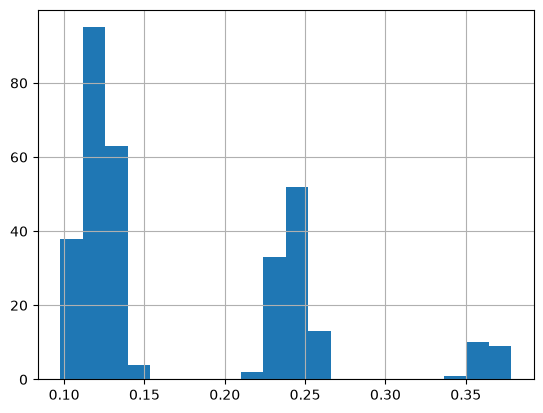

In [32]:
import numpy as np

# initial states analysis: how far are bricks apart initially (ie do we need to consider bricks obstructing grasps)
# recall ex4: the CLEAR is approx 0.1m

# bricks, lat = data["tier1"][0]
# b1 = bricks[0]
# Lattice._stud_centres(*b1.initial[:2], b1.type, b1.initial_yaw)

tier = "tier2"

dists = []
for bricks, lat in data[tier]:
    for i in range(len(bricks)):
        for j in range(i):
            b1 = bricks[i]
            b2 = bricks[j]

            # studs1 = lat._stud_centres(b1)
            # studs2 = lat._stud_centres(b2)

            dists.append({
                "n": len(bricks),
                "dist": np.linalg.norm(np.array(b2.initial) - np.array(b1.initial))
            })
            # dists.append(np.linalg.norm(np.array(b2.initial) - np.array(b1.initial)))

# dists_series = pd.Series(dists)
# print(dists_series.describe())
# dists_series.hist(bins=20)

dists_df = pd.DataFrame(dists)
# dists_df.groupby("n").hist()
print(dists_df.dist.describe())
dists_df.dist.hist(bins=20)

<Axes: xlabel='init_x', ylabel='init_y'>

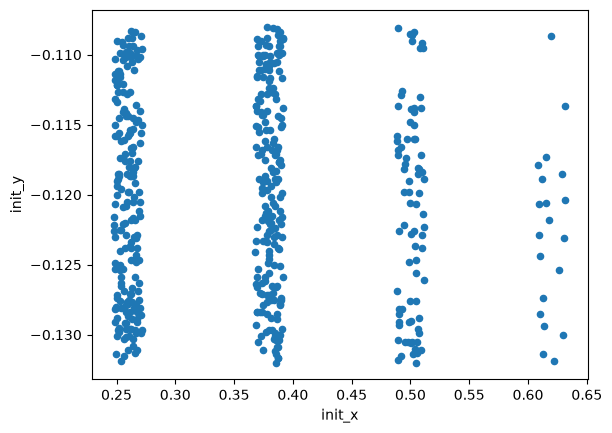

In [88]:
# brick_inits_df = pd.DataFrame([(*b.initial, i) for i, (bricks, _) in enumerate(data["tier2"]) for b in bricks], columns=["x", "y", "z", "task"])
brick_inits_df = bricks_df#[bricks_df.tier == "tier2"]
bricks_df.plot.scatter(x="init_x", y="init_y")

<Axes: xlabel='anchor_ix', ylabel='layer'>

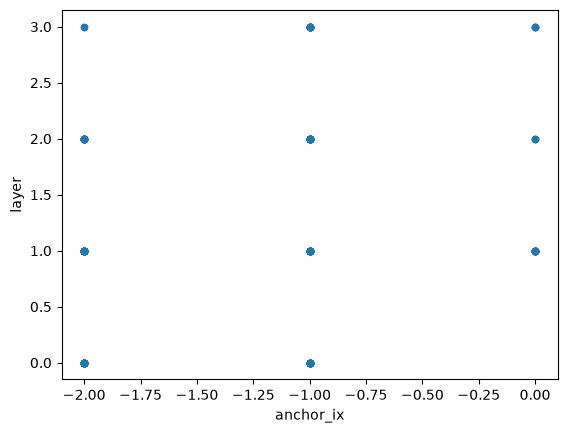

In [92]:
# brick_targets_df = pd.DataFrame([b.center for bricks, _ in data["tier2"] for b in bricks], columns=["x", "y", "z"])
bricks_df.plot.scatter(x="anchor_ix", y="layer")

In [ ]:
# target geometry analysis

# what is largest "tower"/stacking of bricks in the target

from yaml_loader import supporters

bricks, lat = data["tier2"][0]
# print(len(bricks))
b1 = bricks[0]
supps = supporters(bricks)  # supporter dict/graph is DAG

def largest_stacking(supps):
    def largest_stacking_from(supps, brick_name):
        if not supps[brick_name]:
            return 1

        return 1 + max(largest_stacking_from(supps, child.name) for child, _ in supps[brick_name])

    return max(largest_stacking_from(supps, b) for b in supps)

ls1 = pd.Series([largest_stacking(supporters(bricks)) for bricks, _ in data["tier1"]])
print(ls1.value_counts())

ls2 = pd.Series([largest_stacking(supporters(bricks)) for bricks, _ in data["tier2"]])
print(ls2.value_counts())
# bricks_df[bricks_df.tier == "tier2"].groupby("task_id")["layer"].max().value_counts()

2    100
Name: count, dtype: int64
3    60
2    20
4    20
Name: count, dtype: int64


layer
2    60
1    20
3    20
Name: count, dtype: int64

In [7]:
# maybe a sort of graph with edge thickness representing connections

# Domain Analysis

In [8]:
from run_solver import FDResult, run_fast_downward
import glob

FD = Path("..").resolve() / "downward/fast-downward.py"

## Coarse Domain

In [9]:
results: list[FDResult] = []
domain_res_data = []
for tier in ["tier1", "tier2"]:
    for problem in sorted(glob.glob(f"problems_coarse/{tier}/*.pddl")):
        r = run_fast_downward(FD, "pddl/coarse/lego_coarse.pddl", problem, timeout=120, save_raw_out=False)
        results.append(r)
        domain_res_data.append({"tier": tier, "task": problem, "solved": r.solved, "expanded": r.expanded_states, "time": r.planner_time})

In [10]:
results[:5]

[FDResult(solved=True, unsolvable=False, timed_out=False, wall_time=0.12672686576843262, planner_time=0.07, expanded_states=9, plan=['(pick 4x2_brick_1 pick_4x2_brick_1)', '(place 4x2_brick_1 asm_4x2_brick_1)', '(pick 4x2_brick_2 pick_4x2_brick_2)', '(stack 4x2_brick_2 4x2_brick_1 asm_4x2_brick_1)'], plan_length=4, exit_code=0, raw_output=None),
 FDResult(solved=True, unsolvable=False, timed_out=False, wall_time=0.09872603416442871, planner_time=0.07, expanded_states=9, plan=['(pick 2x2_brick_1 pick_2x2_brick_1)', '(place 2x2_brick_1 asm_2x2_brick_1)', '(pick 2x2_brick_2 pick_2x2_brick_2)', '(stack 2x2_brick_2 2x2_brick_1 asm_2x2_brick_1)'], plan_length=4, exit_code=0, raw_output=None),
 FDResult(solved=True, unsolvable=False, timed_out=False, wall_time=0.09890508651733398, planner_time=0.06, expanded_states=9, plan=['(pick 4x2_brick_1 pick_4x2_brick_1)', '(place 4x2_brick_1 asm_4x2_brick_1)', '(pick 4x2_brick_2 pick_4x2_brick_2)', '(stack 4x2_brick_2 4x2_brick_1 asm_4x2_brick_1)'], pl

In [11]:
sols_df = pd.DataFrame(domain_res_data)
print(len(sols_df), sols_df.solved.all())
sols_df

200 True


,tier,task,solved,expanded,time
0,tier1,problems_coarse/tier1/task_001.pddl,True,9,0.07
1,tier1,problems_coarse/tier1/task_002.pddl,True,9,0.07
2,tier1,problems_coarse/tier1/task_003.pddl,True,9,0.06
3,tier1,problems_coarse/tier1/task_004.pddl,True,9,0.07
4,tier1,problems_coarse/tier1/task_005.pddl,True,9,0.08
...,...,...,...,...,...
195,tier2,problems_coarse/tier2/task_096.pddl,True,138,0.06
196,tier2,problems_coarse/tier2/task_097.pddl,True,11,0.06
197,tier2,problems_coarse/tier2/task_098.pddl,True,11,0.06
198,tier2,problems_coarse/tier2/task_099.pddl,True,161,0.06


count    200.000000
mean       0.065500
std        0.008067
min        0.060000
25%        0.060000
50%        0.060000
75%        0.070000
max        0.100000
Name: time, dtype: float64


<Axes: >

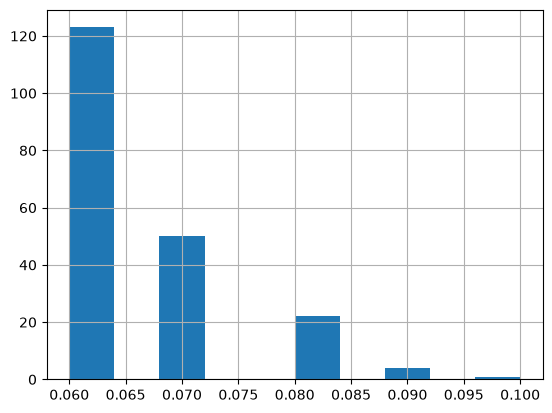

In [12]:
print(sols_df.time.describe())
sols_df.time.hist(bins=10)  # first is outlier, prolly warmup